# CodeAlpha - Task-2. Unemployment Analysis with Python

## 1. Import Required Libraries

In [10]:
# Import libraries for data analysis and visualization

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset

### 2.1 Load unemployment dataset into DataFrame

In [11]:
# Load unemployment dataset into DataFrame :

df = pd.read_csv('Given Datasets/Unemployment in India.csv')

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


### 2.2 Load Covid unemployment dataset

In [12]:
# Load Covid unemployment dataset :

df_covid = pd.read_csv('Given Datasets/Unemployment_Rate_upto_11_2020.csv')

df_covid.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


## 3. Dataset Overview

In [13]:
# Check number of rows and columns:
print('Shape:', df.shape)

# Display column names in list :
print('\nColumns:\n', df.columns.tolist())

# Get dataset information :
print('\nInfo:')
print(df.info())

# Statistical summary of numerical columns
print('\nDescribe:\n', df.describe())

# Check missing values and give sum of all null values by column
print('\nMissing Values:\n', df.isnull().sum())

Shape: (768, 7)

Columns:
 ['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']

Info:
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    str    
 1    Date                                     740 non-null    str    
 2    Frequency                                740 non-null    str    
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 42.1 KB
None

Describe:
        Estimated Unempl

## 4. Data Cleaning

In [16]:
# Remove extra spaces from column names :
df.columns = df.columns.str.strip()

# Remove duplicate records :
df = df.drop_duplicates()

# Fill missing values using forward fill method :
df = df.ffill()

# Convert Date column into datetime format :
if 'Date' in df.columns:
    df['Date'] = df['Date'].str.strip()   # Remove extra spaces
    df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
print(df.isnull().sum(),"\n")

# Display cleaned data :
df.head()


Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64 



,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


## 5. Exploratory Data Analysis (EDA)

### 1.Distribution Analysis

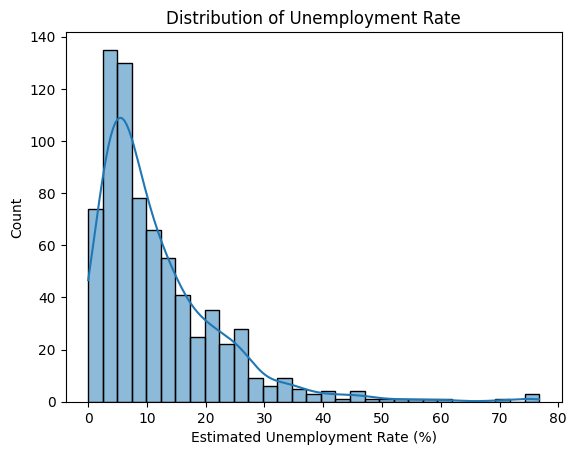

In [17]:
# Create histogram to visualize distribution of unemployment rates :

sns.histplot(df['Estimated Unemployment Rate (%)'], kde=True)
plt.title('Distribution of Unemployment Rate')

plt.show()

In [ ]:
# Found from the analysis :
# Most unemployment rates are concentrated at lower values (around 5–15%).
# The distribution is positively skewed, indicating a few periods/regions
# experienced unusually high unemployment.

### 2.Trend Analysis

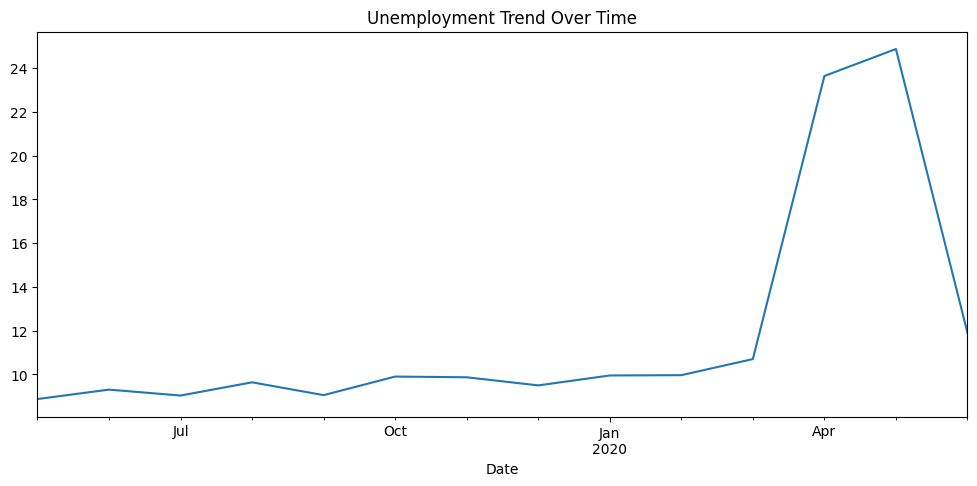

In [18]:
# Create line graph to show unemployment trend over time :

monthly = df.groupby('Date')['Estimated Unemployment Rate (%)'].mean()
monthly.plot(figsize=(12,5))
plt.title('Unemployment Trend Over Time')

plt.show()

In [ ]:
# Found from the analysis :
# Unemployment remained relatively stable initially and later showed
# a sharp increase around the Covid period, followed by a gradual decline.
# This suggests a temporary economic disruption.

### 3.Correlation Analysis

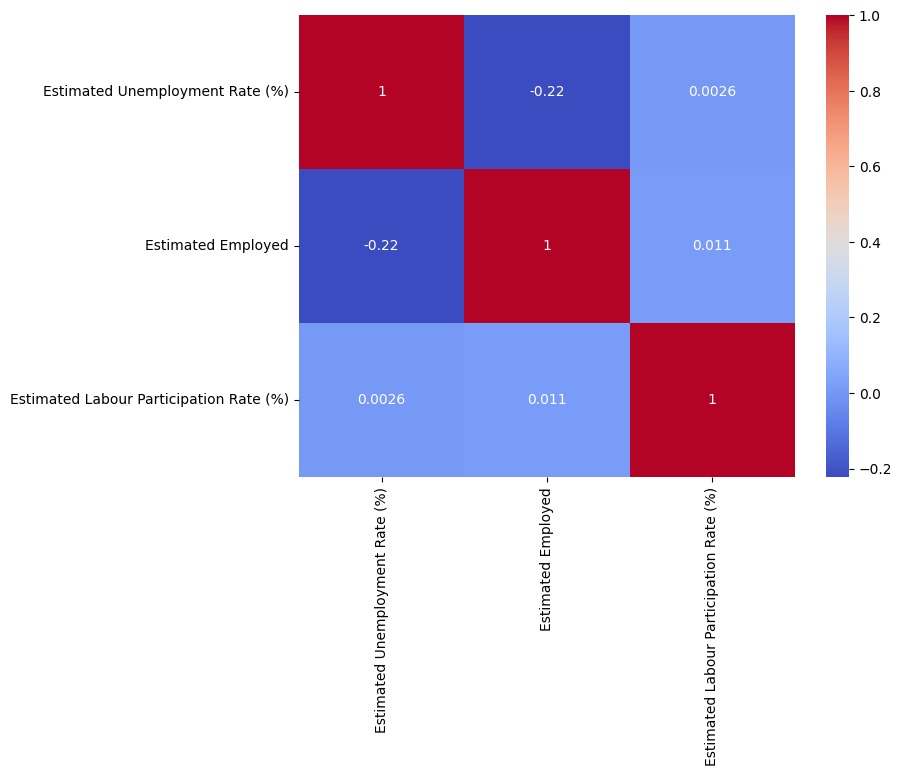

In [27]:
# Show correlation values inside boxes by Selecting only numerical columns and 
# calculate correlation :

plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')

plt.show()

In [ ]:
# Found from the analysis :
# Estimated Unemployment Rate (%) shows a weak negative correlation
# with Estimated Employed and almost no correlation with Labour Participation Rate.
# No strong linear relationship is observed.

### 4.Data Visualization

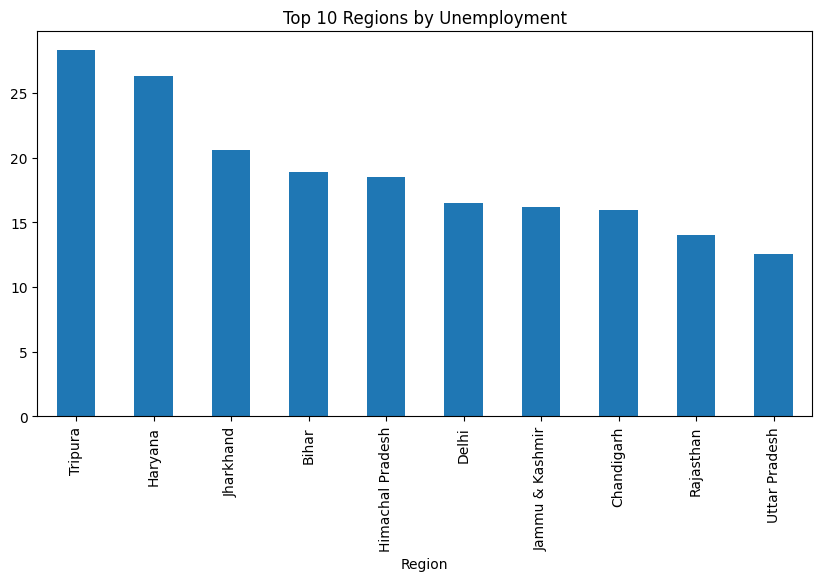

In [20]:
# Create bar chart for Select top 10 regions with highest unemployment :

state = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending = False).head(10)
state.plot(kind = 'bar', figsize = (10,5))
plt.title('Top 10 Regions by Unemployment')

plt.show()

In [ ]:
# Found from the analysis :
# Tripura and Haryana recorded the highest average unemployment rates.
# Regional differences indicate uneven employment conditions across locations.

### Line Chart

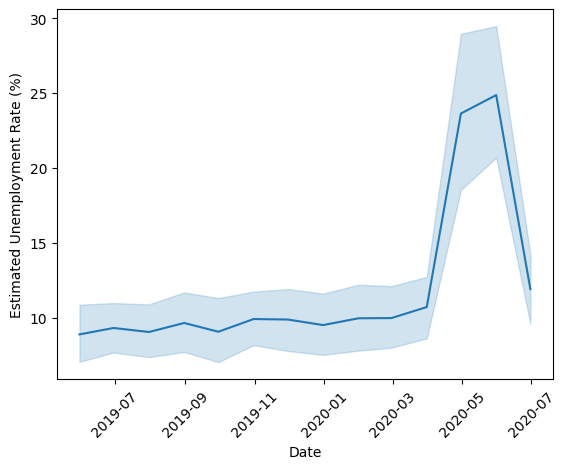

In [21]:
# Create line chart to visualize unemployment trend over time :

sns.lineplot(data = df,x = 'Date',y = 'Estimated Unemployment Rate (%)')
plt.xticks(rotation = 45)

plt.show()

In [ ]:
# Found from the analysis :
# The unemployment rate remained moderate for most periods but increased
# significantly during specific months, indicating economic instability.

## 6. Covid-19 Impact Analysis

In [23]:
# Compare unemployment before and after Covid :

df_covid.columns = df_covid.columns.str.strip()

df_covid['Date'] = pd.to_datetime(df_covid['Date'], dayfirst = True)


before = df_covid[df_covid['Date'] < '2020-03-01']['Estimated Unemployment Rate (%)'].mean()
after = df_covid[df_covid['Date'] >= '2020-03-01']['Estimated Unemployment Rate (%)'].mean()

# Print results :
print('Before Covid:',before)
print('After Covid:',after)
print('Change:', round(after-before,2))


# Found from the analysis :
# Average unemployment increased from 9.23% to 12.96% after Covid.
# The increase of approximately 3.73 percentage points highlights
# the impact of the pandemic on employment conditions.

Before Covid: 9.231346153846154
After Covid: 12.963860465116278
Change: 3.73


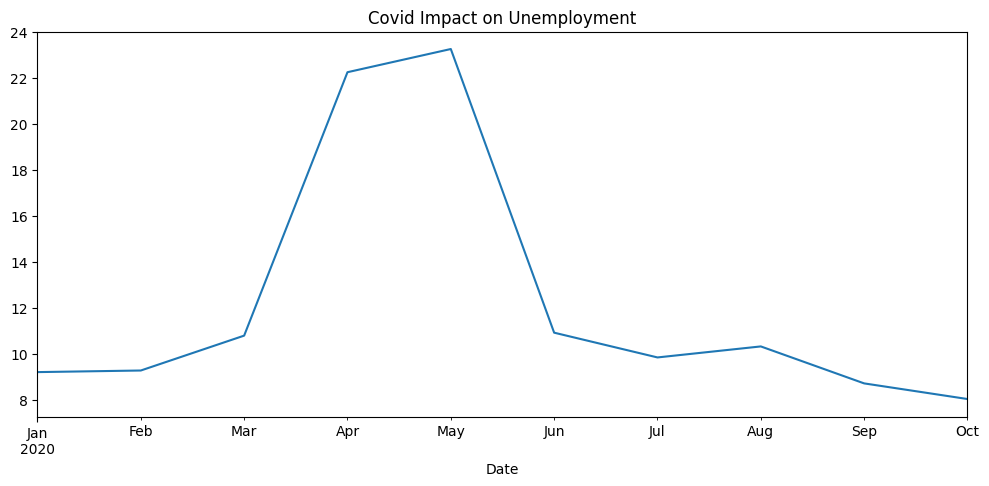

In [24]:
# Analyze unemployment changes during Covid period :

monthly = df_covid.groupby('Date')['Estimated Unemployment Rate (%)'].mean()
monthly.plot(figsize = (12,5))
plt.title('Covid Impact on Unemployment')

plt.show()

In [ ]:
# Found from the analysis :
# A noticeable spike in unemployment was observed during the initial
# Covid months (April–May), followed by recovery in later months.

In [26]:
# Save cleaned dataset to a specific location :

save_path = r"D:\Internship\CodeAlpha\TASK_2\Output\cleaned_Unemployment_Analysis.csv"

df.to_csv(save_path, index=False)

print("Cleaned dataset saved successfully!")


# Found from the analysis :
# The dataset was successfully cleaned and exported for future
# analysis and reproducibility.

Cleaned dataset saved successfully!


## 7. Key Insights
1. Unemployment sharply increased during early Covid months.
2. Regional differences indicate uneven economic impact.
3. Labour participation and unemployment show measurable relationships.
4. Some states recovered faster than others.
5. Monthly patterns suggest seasonal variation.

## 8. Conclusion
The analysis shows unemployment changed significantly during the Covid period. Data cleaning, trend analysis and visualizations reveal regional variation and support policy-focused decisions.